In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
df = pd.read_csv("./Dataset/house_price.csv")
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [23]:
x_train = df[
    [
        "bedrooms",
        "bathrooms",
        "sqft_living",
        "sqft_lot",
        "floors",
        "waterfront",
        "view",
        "condition",
        "sqft_above",
        "sqft_basement",
        "yr_built",
        "yr_renovated",
    ]
].to_numpy()
y_train = df["price"].to_numpy().round(2)

In [24]:
#  Feature Scaling
def zscore_normalize_feature(x: np.ndarray):
    # axis = 0 is mean for every feature
    mu = x.mean(axis=0)
    sigma = x.std(axis=0)

    x_norm = (x - mu) / sigma

    return x_norm, mu, sigma

In [25]:
x_norm, x_mu, x_sigma = zscore_normalize_feature(x_train)

In [26]:
m = x_train.shape[0]  # no of training examples
n = x_train.shape[1]  # no of features
m, n

(4600, 12)

In [27]:
w = np.zeros(n)
b = 0.0
learning_rate = 0.01  # for z score normalized
iterations = 2000

# regularization parameter
lambda_ = 0.1

In [28]:
def compute_output(x: np.ndarray, w: np.ndarray, b) -> np.ndarray:
    return np.dot(x, w) + b

In [29]:
def compute_cost(x: np.ndarray, y: np.ndarray, w: np.ndarray, b, lambda_):
    m = x.shape[0]

    y_hat = compute_output(x, w, b)  # m x 1

    sq_error = (y_hat - y) ** 2

    # with regularization
    reg_term = (lambda_ / (2 * m)) * np.sum(w**2)
    cost = np.sum(sq_error) / (2 * m) + reg_term

    return cost

In [30]:
def compute_gradient(x: np.ndarray, y: np.ndarray, w: np.ndarray, b):
    m = x.shape[0]

    y_hat = compute_output(x, w, b)

    error = y_hat - y

    dj_dw = np.dot(x.T, error) / m
    dj_db = np.sum(error) / m

    return dj_dw, dj_db

In [31]:
def gradient_descent(
    x: np.ndarray, y: np.ndarray, w_init: np.ndarray, b_init, alpha, iterations, lambda_
):
    w = w_init.copy()
    b = b_init

    m = x.shape[0]
    n = x.shape[1]

    cost_history = []

    for i in range(iterations):

        dj_dw, dj_db = compute_gradient(x, y, w, b)

        # without regularization
        # w -= alpha * dj_dw

        # with regularization
        w -= alpha * (dj_dw + (lambda_ / m) * w)

        b -= alpha * dj_db

        cost = compute_cost(x, y, w, b, lambda_)
        cost_history.append(cost)

        if i % 100 == 0:
            print(f"Iteration {i}, Cost: {cost}")

    return w, b, cost_history

In [32]:
w_final, b_final, cost_hist = gradient_descent(
    x_norm, y_train, w, b, learning_rate, iterations, lambda_
)

Iteration 0, Cost: 306313303141.81366
Iteration 100, Cost: 146744885823.2531
Iteration 200, Cost: 127862191775.64287
Iteration 300, Cost: 125014030576.06308
Iteration 400, Cost: 124498522612.42563
Iteration 500, Cost: 124374042765.9983
Iteration 600, Cost: 124334110158.53629
Iteration 700, Cost: 124318892013.48682
Iteration 800, Cost: 124312630038.6825
Iteration 900, Cost: 124309970858.2792
Iteration 1000, Cost: 124308824818.43121
Iteration 1100, Cost: 124308326276.60323
Iteration 1200, Cost: 124308107657.57806
Iteration 1300, Cost: 124308010982.30412
Iteration 1400, Cost: 124307967818.13516
Iteration 1500, Cost: 124307948322.22604
Iteration 1600, Cost: 124307939391.58795
Iteration 1700, Cost: 124307935229.54935
Iteration 1800, Cost: 124307933249.02045
Iteration 1900, Cost: 124307932283.08818


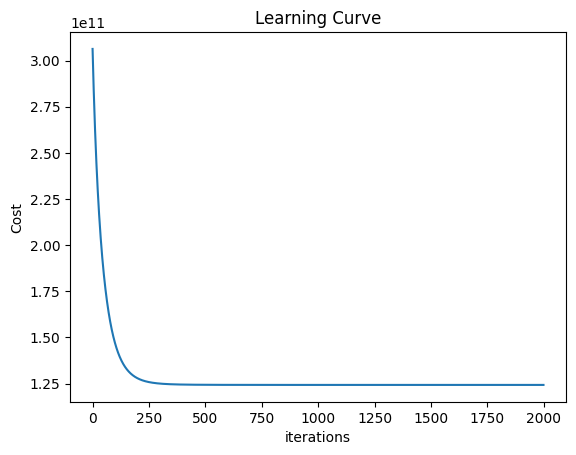

In [33]:
plt.plot(cost_hist)
plt.title("Learning Curve")
plt.xlabel("iterations")
plt.ylabel("Cost")
plt.show()

In [34]:
print(f"Final parameters:\n w = {w_final}\nb = {b_final}")

Final parameters:
 w = [-52731.19995651  44874.44235063 124678.6222018  -24795.40503424
  21414.80104127  29988.10234706  35578.43489687  21570.90883904
 113742.61589119  47455.69853146 -70694.78204271   6446.45249288]
b = 551962.9874408409


In [35]:
y_pred = compute_output(x_norm, w_final, b_final)

ss_res = np.sum((y_train - y_pred) ** 2)
ss_tot = np.sum((y_train - np.mean(y_train)) ** 2)

r2 = 1 - ss_res / ss_tot

print("R² =", r2)

R² = 0.2177997087529705


In [36]:
bedrooms = float(input("Bedrooms: "))
bathrooms = float(input("Bathrooms: "))
sqft_living = float(input("Sqft Living: "))
sqft_lot = float(input("Sqft Lot: "))
floors = float(input("Floors: "))
waterfront = float(input("Waterfront (0 or 1): "))
view = float(input("View Rating: "))
condition = float(input("Condition Rating: "))
sqft_above = float(input("Sqft Above: "))
sqft_basement = float(input("Sqft Basement: "))
yr_built = float(input("Year Built: "))
yr_renovated = float(input("Year Renovated (0 if none): "))

# creating feature vector
x_user = np.array(
    [
        bedrooms,
        bathrooms,
        sqft_living,
        sqft_lot,
        floors,
        waterfront,
        view,
        condition,
        sqft_above,
        sqft_basement,
        yr_built,
        yr_renovated,
    ]
)

x_user_norm = (x_user - x_mu) / x_sigma

# prediction
predicted_price = compute_output(x_user_norm, w_final, b_final)

print(f"\nPredicted House Price: ${predicted_price:,.2f}")

ValueError: could not convert string to float: ''